In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


{'CH1': np.float64(-36.7106609375),
 'CH2': np.float64(-0.40513034375),
 'CH4': np.float64(-3.705905625)}

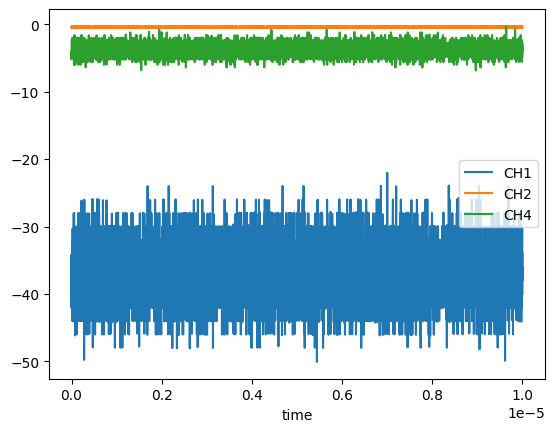

In [2]:
df0= pd.read_csv('2026-01-06_17-17-57-819.csv')
df0.plot(x='time', y=['CH1','CH2','CH4'])
vals0={}
for c in ['CH1','CH2','CH4']: 
    vals0[c]=df0[c].mean() 
vals0

In [3]:
list_ = """351.2V
2026-01-06_17-43-30-844
377.5v
2026-01-06_17-45-21-093
401.9v
2026-01-06_17-46-24-611
427.4v
2026-01-06_17-48-22-544""".split("\n")
voltages = list_[::2][::-1]
files = list_[1::2][::-1]

In [4]:
from utils import *
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

In [5]:
import sklearn

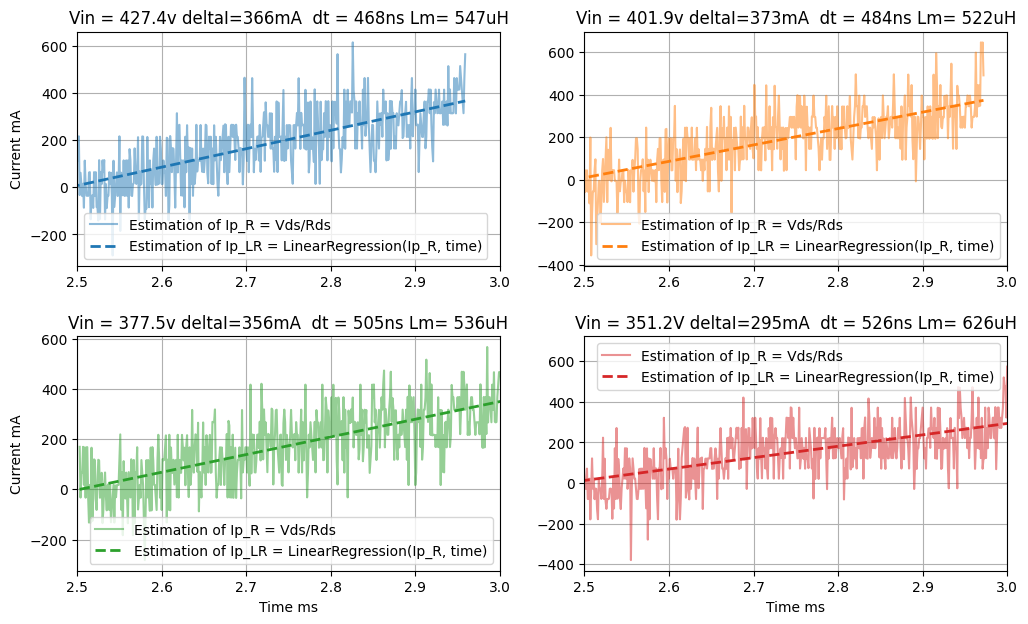

In [6]:
fig , axs = plt.subplots(2,2, figsize=(12,7))
fig.subplots_adjust(hspace=0.3)
axs = axs .flatten()
k=0
arr  = []
for vol, f in zip(voltages, files): 
    f=f+".csv"
    df= pd.read_csv(f)
    Vds= df.CH1.values-vals0["CH1"]
    Vs= df.CH4.values-vals0["CH4"]
    Is= df.CH2.values-vals0["CH2"]
    time = df.time.values*1e6
    Is=Is-Is[:1000].mean()
    i= trigger(Vds, thresh=200, transition='fall')[0]+40
    j= trigger(Vds, thresh=200, transition='rise')[0]-60
    
    vds = Vds[i:j]
    t = time[i:j]
    m= sklearn.linear_model.LinearRegression()
    Rds =40
    m.fit(t.reshape((-1,1)),vds/Rds)
    ic=m.predict(t.reshape((-1,1)))
    iest=vds/Rds
    dt = t[-1]-t[0]
    di = ic[-1]-ic[0]
    V0= float(vol.lower().replace("v", ""))
    # v = L di/dt
    Lm= V0/(di/dt)
    
    axs[k].plot(t,1e3*(iest-ic[0]), label = f"Estimation of Ip_R = Vds/Rds", alpha = 0.5, c=f"C{k}")
    axs[k].plot(t,1e3*(ic-ic[0]), label =f"Estimation of Ip_LR = LinearRegression(Ip_R, time)",
             linestyle= "--", linewidth=2, c=f"C{k}")

    axs[k].set_title(f'Vin = {vol} deltaI={1e3*(ic.max()-ic.min()):0.0f}mA  dt = {1e3*dt:0.0f}ns Lm= {Lm:0.0f}uH')
    
    



    dic = {"Vin":float(vol.lower().replace("v","")),
           "dt_ns":1000*dt, 
           "di_mA": 1e3*(ic.max()-ic.min()), 
            "Lm_uH": Lm}
    arr.append(dic)
    axs[k].legend()
    axs[k].grid()
    axs[k].set_xlim([2.5,3])


    k=k+1

    
axs[0 ].set_ylabel("Current mA")
axs[2 ].set_ylabel("Current mA")
axs[2].set_xlabel("Time ms")
axs[3 ].set_xlabel("Time ms")


fig.savefig("Tny264_Estimation_of_lm.png", bbox_inches="tight")

In [7]:
dfL=pd.DataFrame(arr).astype(int)
print(dfL.to_string(index=False))

 Vin  dt_ns  di_mA  Lm_uH
 427    468    365    546
 401    484    372    522
 377    505    355    535
 351    525    295    625


In [8]:
#%pip install tabulate

In [9]:
print(dfL.to_markdown(index=False))

|   Vin |   dt_ns |   di_mA |   Lm_uH |
|------:|--------:|--------:|--------:|
|   427 |     468 |     365 |     546 |
|   401 |     484 |     372 |     522 |
|   377 |     505 |     355 |     535 |
|   351 |     525 |     295 |     625 |


|   Vin |   dt_ns |   di_mA |   Lm_uH |
|------:|--------:|--------:|--------:|
|   427 |     468 |     365 |     546 |
|   401 |     484 |     372 |     522 |
|   377 |     505 |     355 |     535 |
|   351 |     525 |     295 |     625 |

<Axes: xlabel='Vin'>

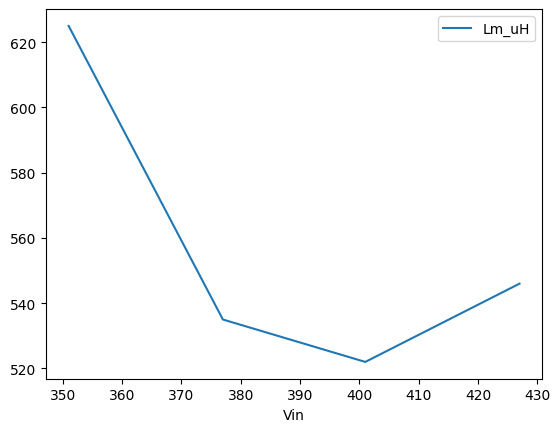

In [10]:
dfL.plot(x= "Vin", y= "Lm_uH")

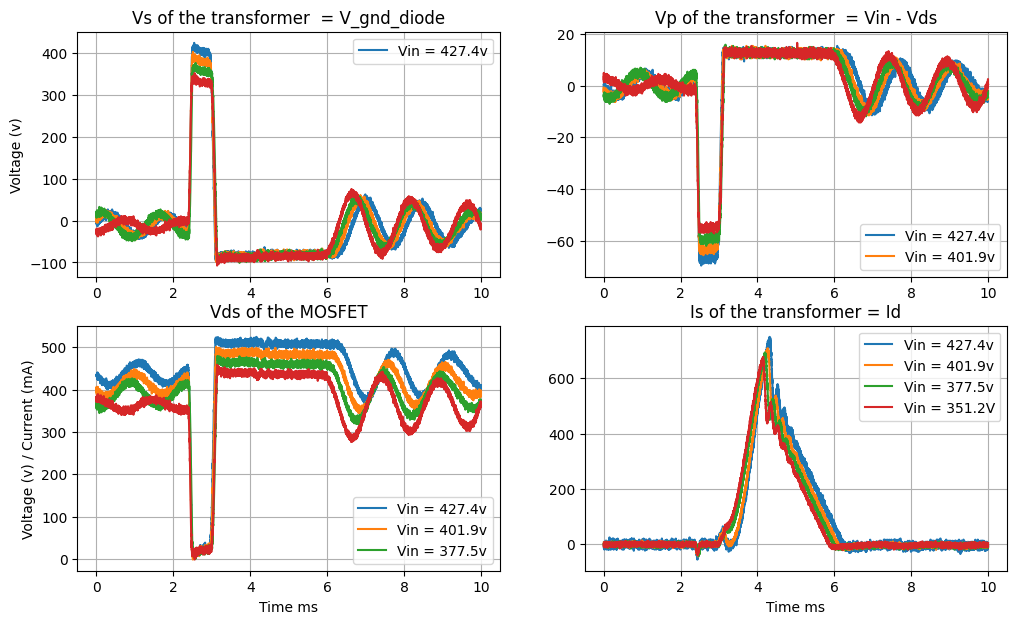

In [11]:
fig , axs = plt.subplots(2,2, figsize=(12,7))
axs = axs .flatten()
k=0
for vol, f in zip(voltages, files): 
    f=f+".csv"
    df= pd.read_csv(f)
    Vds= df.CH1.values-vals0["CH1"]
    Vs= df.CH4.values-vals0["CH4"]
    Is= df.CH2.values-vals0["CH2"]
    Is=Is-Is[:1000].mean()
    time = df.time.values*1e6
    axs[2].plot(time, Vds, label = f"Vin = {vol}")
    V0= float(vol.lower().replace("v" ,""))
    axs[0].plot(time,V0- Vds, label = f"Vin = {vol}")
    axs[1].plot(time, Vs, label = f"Vin = {vol}")
    axs[3].plot(time, 1000*Is, label = f"Vin = {vol}")




    axs[k].legend()
    axs[k].grid()
    #axs[k].set_xlim([2.5,3])


    k=k+1

    
axs[0 ].set_ylabel("Voltage (v)")
axs[2 ].set_ylabel("Voltage (v) / Current (mA)")
axs[2].set_xlabel("Time ms")
axs[3 ].set_xlabel("Time ms")
axs[1 ].set_title("Vp of the transformer  = Vin - Vds")
axs[2 ].set_title("Vds of the MOSFET")
axs[0 ].set_title("Vs of the transformer  = V_gnd_diode")
axs[3 ].set_title("Is of the transformer = Id")
    
#axs[0].legend()
#axs[4].legend()

fig.savefig("Tny264_time_meas.png", bbox_inches="tight")

In [12]:
0.7*4/26

0.10769230769230768

In [13]:
vout2 =11.35
vd2 = 0.5
Vs0 = Vs[3500:4000].mean()
Vs0, vout2+vd2

(np.float64(12.666999375), 11.85)

1.1449999999999996 us


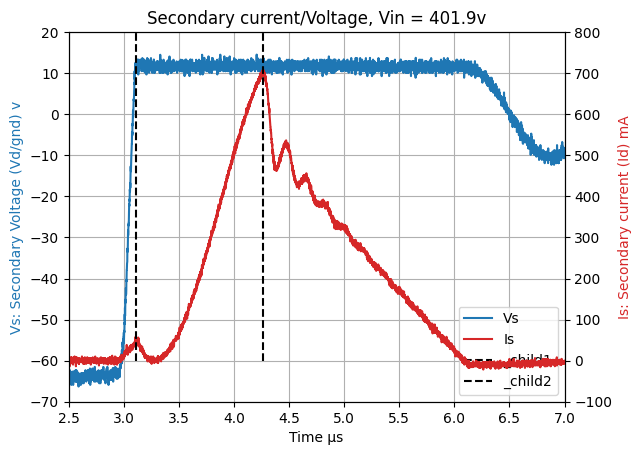

In [14]:
vol = "401.9v"
f= "2026-01-06_17-46-24-611"
f=f+".csv"
df= pd.read_csv(f)
Vds= df.CH1.values-vals0["CH1"]
Vs= df.CH4.values-vals0["CH4"]
Vs = Vs - Vs0 + (vout2+vd2)
Is= df.CH2.values-vals0["CH2"]
Is=Is-Is[:1000].mean()
time = df.time.values*1e6

V0= float(vol.lower().replace("v" ,""))


fig, ax = plt.subplots()
ax.plot(time, Vs, label = f"Vs", color='C0')
ax2 = ax.twinx()
ax2.plot(time, 1e3*Is, label = f"Is", color='C3')
ax.set_xlim([2.5,7])
t0=3.115
t1=4.26
dt=t1-t0
print(dt,"us")
ax2.plot([t0,t0],[0,800], c="k", linestyle = "--")
ax2.plot([t1,t1],[0,800], c="k", linestyle = "--")
#plt.plot(time, 1e2*Is, label = f"Vin = {vol}")


ax.set_ylabel('Vs: Secondary Voltage (Vd/gnd) v', color='C0')
ax2.set_ylabel('Is: Secondary current (Id) mA', color='C3')

ax.set_ylim([ -70, 20])
ax2.set_ylim([ -100,800 ])

ax.grid()
ax.set_xlabel ("Time µs")

lines = ax.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax.legend(lines, labels)
ax.set_title("Secondary current/Voltage, Vin = "+vol)
fig.savefig("Tny264_zoom_Is.png", bbox_inches="tight")

1.1750000000000003 us


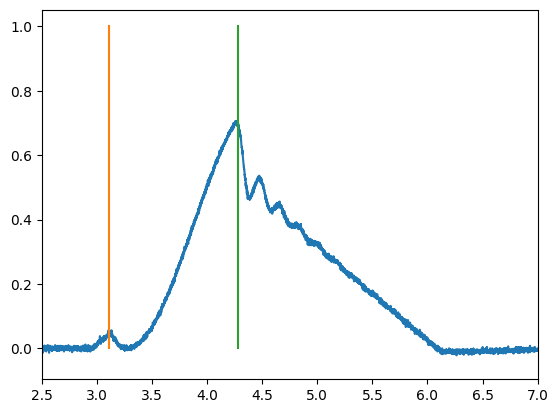

In [15]:
plt.plot(time, Is, label = f"Vin = {vol}")
plt.xlim([2.5,7])
t0=3.11
t1=4.285
dt=t1-t0
print(dt,"us")
plt.plot([t0,t0],[0,1])
plt.plot([t1,t1],[0,1])

<Axes: xlabel='time'>

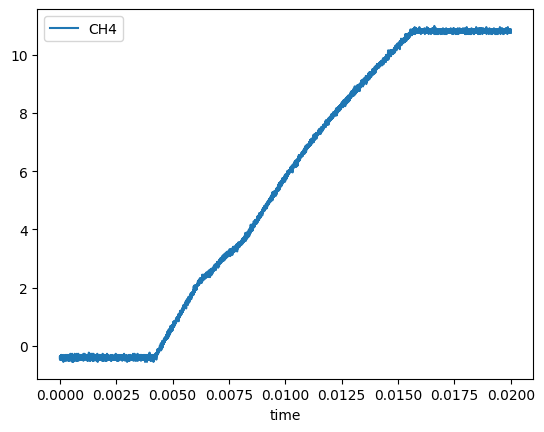

In [16]:

df= pd.read_csv('2026-01-06_18-10-59-970.csv')
time = df.time.values
Vout = df.CH4.values

df.plot(x="time",y="CH4")

In [17]:
df.Ts.iloc[0]*10e3

np.float64(0.02)

270
610
880


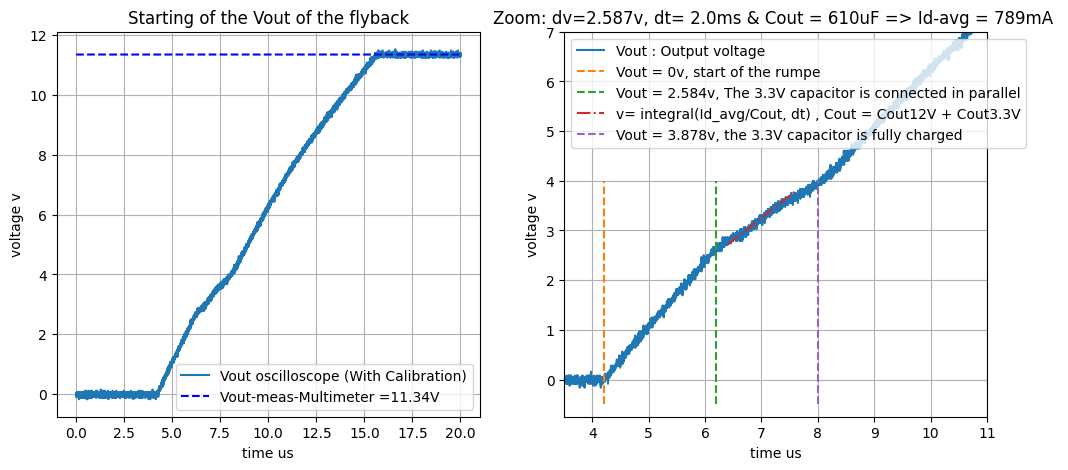

In [19]:
C33=220+10+10*4
print(C33)
Cout = 470+10+100+10+10+10
Cout
print(Cout)
Cout2=Cout+C33
print(Cout2)


fig , axs = plt.subplots(1,2, figsize=(12,5))
axs = axs .flatten()


VoutMes= 11.34
Vout = Vout-Vout[:1000].mean()

Vf= Vout[-1000:].mean()
Vout = VoutMes*Vout/Vf
axs[0].plot(time*1e3, Vout, label = "Vout oscilloscope (With Calibration)")
axs[0].plot(time*1e3, [VoutMes]*len(Vout),linestyle = "--", c="b", label="Vout-meas-Multimeter =11.34V")
axs[0].grid()
axs[0].legend()
axs[0].set_xlabel("time us")
axs[0].set_ylabel("voltage v")
axs[0].set_title("Starting of the Vout of the flyback")







plt.plot(time*1e3, Vout, label= "Vout : Output voltage")
plt.grid()

plt.xlim([3.5, 11])
plt.ylim([None, 7])

t0=4.2
t1=6.2

i= np.argmin(np.abs(time*1e3-t0))
j= np.argmin(np.abs(time*1e3-t1))
dv = Vout[j]-Vout[i]
dt= t1-t0


plt.plot([t0,t0],[-0.5,4], label = "Vout = 0v, start of the rumpe"
    ,linestyle = "--")
plt.plot([t1,t1],[-0.5,4], label = f"Vout = {Vout[j]:.3f}v, The 3.3V capacitor is connected in parallel"
    ,linestyle = "--")

Iout = 1e3 * Cout*1e-6*dv/(dt*1e-3) #  i = c dv/dt
plt.title(f"Zoom: dv={dv:.3f}v, dt= {dt:.1f}ms & Cout = {Cout}uF => Id-avg = {Iout:0.0f}mA ")




# i = c dv/dt
v2 = (Iout*1e-3/(Cout2*1e-6))*(time-t1*1e-3)+Vout[j]-0.05
t=time*1e3
m= t>t1+0.2
t=t[m]
v2=v2[m]
plt.plot(t[:600], v2[:600], label = "v= integral(Id_avg/Cout, dt) , Cout = Cout12V + Cout3.3V"
         ,linestyle = "dashdot")
t2=8
K= np.argmin(np.abs(time*1e3-t2))
plt.plot([t2,t2],[-0.5,4], label = f"Vout = {Vout[K]:.3f}v, the 3.3V capacitor is fully charged "
    ,linestyle = "--")
#plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.xlabel("time us")
plt.ylabel("voltage v")
fig.savefig("Tny264_Vout_start.png", bbox_inches="tight")

In [20]:
# Vdp = 5.877 5.878

In [21]:
C33

270

In [22]:
Iout = 1e3 * Cout*1e-6*dv/(dt*1e-3) #  i = c dv/dt
Iout, Cout, dv, dt

(np.float64(789.0157833953549), 610, np.float64(2.5869369947388687), 2.0)

In [23]:
t

array([ 6.402,  6.404,  6.406, ..., 19.994, 19.996, 19.998], shape=(6799,))

In [24]:
dtp=600e-9 # vin=345
Freq =132e3
DC=Freq*dtp 
DC, "DutyCy"

(0.07919999999999999, 'DutyCy')

In [25]:

Np, Ns =26,4
#IpAvg=Freq*Iinpeak *dtp/2
#IsAvg=Iout
#Is = Np/Ns Ip 
#Iout  =   Np/Ns * Freq*Iinpeak *dtp/2 # DC=Freq*dtp
Iinpeak = Iout  *(Ns/Np)/(DC/2)
Iinpeak  # Nok i expect

np.float64(3065.329383820338)

In [26]:
Np/Ns * Freq*Iinpeak *dtp/2

np.float64(789.015783395355)

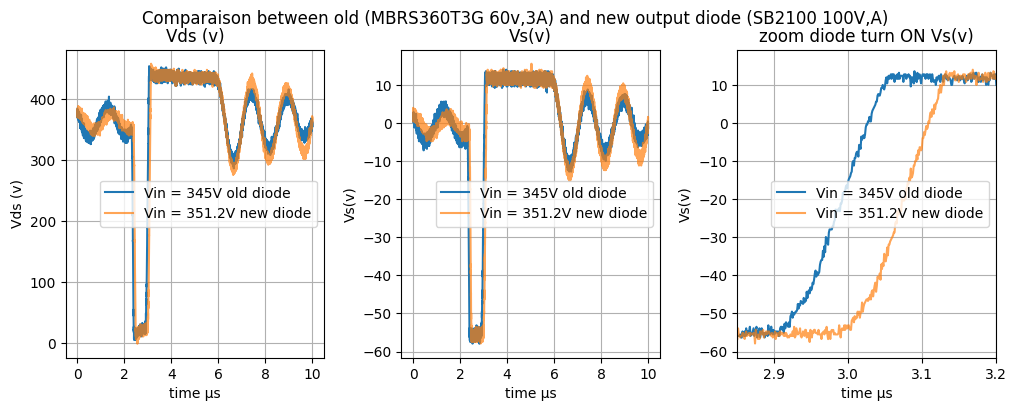

In [27]:
fig , axs = plt.subplots(1,3, figsize=(12,4))
fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(hspace=0.3)
axs = axs .flatten()
k=0
alp=1
for f, lab in  zip (
        (#"2026-01-06_15-58-48-465.csv",
         "2026-01-06_17-16-25-122.csv",
         "2026-01-06_17-43-30-844.csv"), 
         ( "Vin = 345V old diode",#"Vin = 345V old diode (MBRS360T3G 60v,3A)", 
          "Vin = 351.2V new diode") # "Vin = 351.2V new diode (SB2100 100V,A)"
    ): 
    if k==1:
        alp=0.7

    df= pd.read_csv(f)
    Vds= df.CH1.values-vals0["CH1"]
    Vs= df.CH4.values-vals0["CH4"]
    time =df.time.values*1e6
    Vs = Vs - Vs0 + (vout2+vd2)
    Is= df.CH2.values-vals0["CH2"]
    Is=Is-Is[:1000].mean()
    axs[0].plot(time, Vds, label = lab, c=f"C{k}",alpha = alp)
    axs[1].plot(time, Vs, label = lab, c=f"C{k}",alpha = alp)
    #axs[2].plot(time, Is, label = lab, c=f"C{k}")
    axs[2].plot(time, Vs, label = lab, c=f"C{k}",alpha = alp)
    axs[2].set_xlim([2.85,3.2])

    k=k+1
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[0].grid()
axs[1].grid()
axs[2].grid()
axs[0].set_xlabel("time µs")
axs[1].set_xlabel("time µs")
axs[2].set_xlabel("time µs")

axs[0].set_ylabel("Vds (v)")
axs[1].set_ylabel("Vs(v)")
axs[2].set_ylabel("Vs(v)")

axs[0].set_title("Vds (v)")
axs[1].set_title("Vs(v)")
axs[2].set_title("zoom diode turn ON Vs(v)")
fig.suptitle("Comparaison between old (MBRS360T3G 60v,3A) and new output diode (SB2100 100V,A)")

fig.savefig("Tny264_change_out_diode.png", bbox_inches="tight")